# Medieval Latin Span-NER – Demo

This notebook shows what [`ERCDiDip/medieval-latin-span-ner`](https://huggingface.co/ERCDiDip/medieval-latin-span-ner) can do.
The model tags **19 diplomatic entity types** (persons, titles, places, institutions, legal clauses, dates, money, ...) in medieval Latin charters.

* Paper: *Twenty's Plenty: Semantic Scaffolding and Span Architecture for 19-Label NER in Medieval Latin Charters* (Kovács, Consolo, Vogeler; NLP4DH 2026) – see `2026.nlp4dh-1.22.pdf`
* Training data: [Zenodo 10.5281/zenodo.19009431](https://zenodo.org/records/19009431)
* Demo charter: Sigismund to Abbot Demetrius of Tihany, 1416 Aug 10 (`PannHActa_1416_VIII_10_charter.txt`)

Requirements: `pip install torch transformers huggingface_hub matplotlib pandas` (first run downloads ~4.5 GB of weights; a GPU is optional).

## 1. Load the model

In [1]:
from collections import Counter
import pandas as pd
from IPython.display import HTML, display

from medieval_latin_ner import MedievalLatinNER, render_ents, LABEL_COLORS

ner = MedievalLatinNER()   # picks the GPU automatically if available

[1/3] Downloading architecture and weights from ERCDiDip/medieval-latin-span-ner (cached after first run) ...


[2/3] Loading tokenizers (xlm-roberta-large, bge-m3) ...


[3/3] Building model on cuda ...


## 2. The 19 labels
Each label is described to the model by an English phrase (*semantic scaffolding*), which is how it generalises from only a few hundred training sentences.

In [2]:
rows = "".join(
    f'<tr><td><mark style="background:{LABEL_COLORS[l]};color:#000;padding:0.2em 0.5em;border-radius:0.35em;font-weight:bold">{l}</mark></td>'
    f'<td style="text-align:left">{d}</td></tr>' for l, d in ner.label_descriptions.items())
display(HTML(f'<table><tr><th>label</th><th style="text-align:left">description used as prompt</th></tr>{rows}</table>'))

label,description used as prompt
PER,"individual person name without any titles or roles, strictly the given name or family name"
ACTOR,"full noun phrase referring to a person including their name plus noble title, profession, geographic origin, or social status"
TITLE,"social rank, noble title, ecclesiastical office, profession, or papal rank such as comes, abbas, episcopus"
REL,"word or phrase indicating family, kinship, marriage, or social relationship like filius, uxor, frater"
LOC,"geographical place, settlement, city, diocese, region, or named territory"
INS,"monastery, abbey, church, cell, or religious order functioning as a corporate and legal body"
NAT,"natural landscape feature such as a river, stream, forest, mountain, or valley"
EST,"short physical plot of land, estate, farm, meadows, woods, vineyards, or courtyards"
PROP,"detailed boundary description of a property, grange, estate, or island including past owners, movables, and immovables"
LEG,"legal clause declaring rights, conditions, penalties, permissions, or papal commands"


## 3. A short example

In [3]:
sample = "Ego Heinricus comes de Hals dedi ecclesie Sancti Petri in Salzburg tres mansos in villa Perge pro anima patris mei."
display(HTML(render_ents(sample, ner.predict(sample), flat=True)))

/home/tamask/environments/python3/lib/python3.12/site-packages/torch/nn/modules/module.py:1784: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


## 4. Full charter: Sigismund → Abbot of Tihany (1416)
A royal mandate from the Hungarian chancery, a text type that is *not* from the 13th-century Austrian charters the model was trained on.

In [4]:
with open("PannHActa_1416_VIII_10_charter.txt", encoding="utf-8") as f:
    text = f.read().strip()

entities = ner.predict(text, threshold=0.5)   # t=0.5 is the best threshold in the paper
print(f"{len(text.split())} words, {len(entities)} entities")

403 words, 115 entities


### Highlighted text (spaCy/displaCy style)
Like a marker pen: every entity is coloured and carries its label badge. Where entities overlap (e.g.  inside ), this view keeps the highest-scoring one; hover over a span to see its score.

In [5]:
display(HTML(render_ents(text, entities, flat=True)))

#### Persons, places and institutions only
Filtering the same output to the labels most useful for prosopography and place indices.

In [6]:
display(HTML(render_ents(text, entities, flat=True, labels=["PER", "ACTOR", "TITLE", "LOC", "INS"])))

#### Nested view
The model also predicts nested entities (e.g.  and  inside an ). Here the innermost label is shown; hover to see the full chain, e.g. .

In [7]:
display(HTML(render_ents(text, entities, flat=False)))

### Entity table

In [8]:
df = pd.DataFrame(entities)[["label", "text", "score", "start_char", "end_char"]]
df.style.format({"score": "{:.2f}"}).hide(axis="index")

label,text,score,start_char,end_char
PER,Sigismundus,1.00,0,11
TITLE,rex,0.99,34,37
LOC,Hungarie,1.00,57,65
LOC,Croacie,1.00,67,74
PER,Demetrio,1.00,134,142
TITLE,abbati,1.00,144,150
INS,monasterii Sancti Aniani de Tikonio,0.77,151,186
INS,Sancti Aniani de Tikonio,0.82,162,186
INS,Sancti Aniani,0.62,162,175
LOC,de Tikonio,0.87,176,186


### Persons, places and institutions
The same output filtered to the most useful labels for prosopography and place-name indexing.

In [9]:
for label in ["ACTOR", "PER", "TITLE", "LOC", "INS", "DAT"]:
    items = [e for e in entities if e["label"] == label]
    print(f"\n{label} ({len(items)})")
    for e in items:
        print(f"   {e['score']:.2f}  {e['text'][:110]}")


ACTOR (3)
   0.89  domini Nicolai Georgii de Nariag
   0.97  Nicolai Georgii de Nariag
   0.94  Georgii de Nariag

PER (10)
   1.00  Sigismundus
   1.00  Demetrio
   0.85  Nicolai Georgii de Nariag
   0.59  Nicolai Georgii de
   0.97  Nicolai Georgii
   1.00  Nicolai
   1.00  Georgii
   0.53  Ioanne papa
   1.00  Ioanne
   1.00  Ioanni

TITLE (19)
   0.99  rex
   1.00  abbati
   1.00  canonici
   0.53  regnicolas
   1.00  papa
   0.63  archiepiscopo Strigoniensi
   1.00  archiepiscopo
   0.84  aule nostre Romanoregie summo cancellario
   0.79  Romanoregie summo cancellario
   0.52  summo cancellario necnon regni nostri Hungarie vicario
   0.99  summo cancellario
   0.89  cancellario necnon regni nostri Hungarie vicario
   1.00  cancellario
   0.75  Hungarie vicario generali
   0.99  Hungarie vicario
   0.94  vicario generali
   1.00  vicario
   0.96  Strigoniensis vicario
   1.00  vicario

LOC (22)
   1.00  Hungarie
   1.00  Croacie
   0.87  de Tikonio
   1.00  Tikonio
   0.50  de Nar

### Label distribution

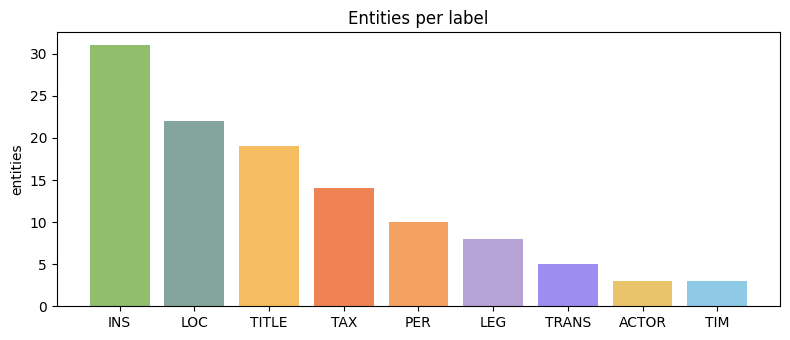

In [10]:
import matplotlib.pyplot as plt
counts = Counter(e["label"] for e in entities)
labels, values = zip(*counts.most_common())
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(labels, values, color=[LABEL_COLORS[l] for l in labels])
ax.set_ylabel("entities"); ax.set_title("Entities per label")
plt.tight_layout(); plt.show()

## 5. Effect of the threshold
A higher threshold gives fewer, more precise entities; a lower one gives more coverage.

In [11]:
rows = [{"threshold": t, "entities": len(ner.predict(text, threshold=t))} for t in (0.3, 0.4, 0.5, 0.6, 0.7)]
pd.DataFrame(rows)

/home/tamask/environments/python3/lib/python3.12/site-packages/torch/nn/modules/module.py:1784: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,threshold,entities
0,0.3,145
1,0.4,128
2,0.5,115
3,0.6,104
4,0.7,96


## 6. Using the model on your own texts

In [12]:
# 1) single string
ner.predict("Datum Wienne anno Domini millesimo ducentesimo quinquagesimo.")

# 2) a text file
# text, ents = ner.predict_file("my_charter.txt", threshold=0.5)

# 3) command line
#    python medieval_latin_ner.py my_charter.txt --html out.html --json out.json

/home/tamask/environments/python3/lib/python3.12/site-packages/torch/nn/modules/module.py:1784: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


[{'label': 'LOC',
  'score': 0.9973,
  'text': 'Wienne',
  'start_char': 6,
  'end_char': 12,
  'start_word': 1,
  'end_word': 1}]

## Notes and limitations

* Trained on 458 sentences from 20 13th-century charters (AT-StiAH, Monasterium.net). Texts from other periods/chanceries (as here) may show lower accuracy – especially for rare labels such as `PROP`, `EST`, `TAX`.
* Test results in the paper: overlap F1 83.4 %, exact F1 67.7 %.
* Annotation guidelines treat `ACTOR` as a full noun phrase that contains `PER`, `TITLE`, `INS`/`LOC`, so nested entities are expected.

## Citation
Kovács, T., Consolo, G., Vogeler, G. (2026). *Twenty's Plenty: Semantic Scaffolding and Span Architecture for 19-Label NER in Medieval Latin Charters.* Proceedings of NLP4DH 2026, pp. 236–241.
Data: Consolo, G., Kovács, T., Vogeler, G. (2026). *Named Entity Recognition Dataset for Medieval Latin Charters.* Zenodo. https://doi.org/10.5281/zenodo.19009431